In [14]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
import choclo
from numpy.linalg import inv
import spherical as sph

In [15]:
TESLA_TO_NANOTESLA = 1e9

ellipsoid = bl.WGS84

coordinates = vd.scatter_points(
    region=(-3, 4, -2, 3),
    size = 1600,
    extra_coords=ellipsoid.mean_radius,
)

longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

magnetic_moments = (
    np.full((1, 1), 0.0e9),  
    np.full((1, 1), 0.0e9),        
    np.full((1, 1), 1.0e9)       
)

dipoles = vd.grid_coordinates(
    region=(0, 0,0, 0),
    shape=(1,1),
    extra_coords=ellipsoid.mean_radius-3e4,
)

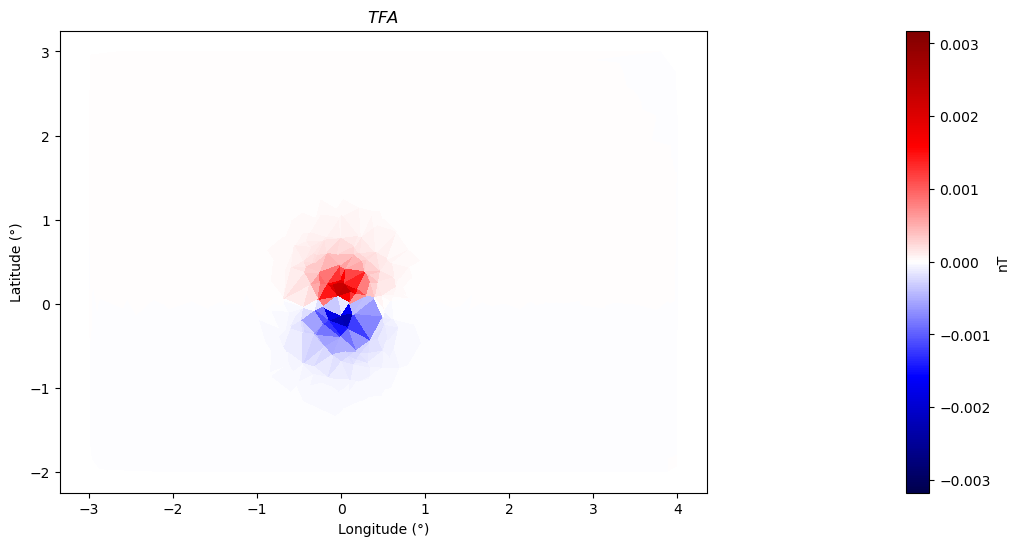

In [16]:
b_long, b_colat, b_radius = sph.foward_modeling_spherical(coordinates, dipoles, magnetic_moments)

observed_data = hm.total_field_anomaly((b_long, -b_colat, b_radius), inclination=0, declination=0)

scale = vd.maxabs(observed_data)

plt.figure(figsize=(15, 6))
plt.tripcolor(longitude, sph_latitude, observed_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('$TFA$')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.axis("scaled")

plt.show()


In [17]:
def jacobian(coordinates, dipoles, magnetic_moments, I_F, D_F):
    """
    """

    coordinates = tuple(c.ravel() for c in coordinates)
    dipoles = tuple(d.ravel() for d in dipoles)
    magnetic_moments = tuple(m.ravel() for m in magnetic_moments)

    n = len(coordinates[0])
    m = len(dipoles[0])
    A = np.empty((n, m))


    for j in range(m):
        dipole = (dipoles[0][j], dipoles[1][j], dipoles[2][j])
        moment = (magnetic_moments[0][j], magnetic_moments[1][j], magnetic_moments[2][j])
        b_latitude, b_colatitude, b_radius = sph.foward_modeling_spherical(coordinates, dipole, moment)

        A[:, j] = TESLA_TO_NANOTESLA * hm.total_field_anomaly((b_latitude, b_colatitude, b_radius),I_F, D_F)

    return A

In [18]:
# def jacobian(coordinates, dipoles, magnetic_moment, I_F, D_F):
#     """
#     """

#     coordinates = tuple(c.ravel() for c in coordinates)
#     dipoles = tuple(d.ravel() for d in dipoles)

#     CM = choclo.constants.VACUUM_MAGNETIC_PERMEABILITY / 4 / np.pi

#     n = len(coordinates[0])
#     m = len(dipoles[0])
#     A = np.empty((n, m))


#     longitude_obs = np.deg2rad(coordinates[0])
#     colatitude_obs = np.pi/2 - np.deg2rad(coordinates[1])
#     radius_observed_data = coordinates[2]

#     B_r = np.zeros(len(coordinates[0]))
#     B_phi = np.zeros(len(coordinates[0]))
#     B_theta = np.zeros(len(coordinates[0]))

#     # Calculate the directional cossines
#     n_dipoles= dipoles[0].size
#     for i in range(n_dipoles):
#       longitude_source = np.deg2rad(dipoles[0][i])
#       colatitude_source = np.pi/2 - np.deg2rad(dipoles[1][i])
#       radius_source = dipoles[2][i]

#       diff_long_obs_long_source = longitude_obs - longitude_source
#       mu_ij = np.cos(colatitude_obs) * np.cos(colatitude_source) + np.sin(colatitude_obs) * np.sin(colatitude_source) * np.cos(diff_long_obs_long_source)
#       ri_dot_thetaj = -np.cos(colatitude_obs) * np.sin(colatitude_source) + np.sin(colatitude_obs) * np.cos(colatitude_source) * np.cos(diff_long_obs_long_source)
#       ri_dot_phij = np.sin(colatitude_obs) * np.sin(diff_long_obs_long_source)
#       thetai_dot_rj = -np.sin(colatitude_obs) * np.cos(colatitude_source) + np.cos(colatitude_obs) * np.sin(colatitude_source) * np.cos(diff_long_obs_long_source)
#       thetai_dot_thetaj = np.sin(colatitude_obs) * np.sin(colatitude_source) + np.cos(colatitude_obs) * np.cos(colatitude_source) * np.cos(diff_long_obs_long_source)
#       thetai_dot_phij = np.cos(colatitude_obs) * np.sin(diff_long_obs_long_source)
#       phii_dot_rj = -np.sin(colatitude_source) * np.sin(diff_long_obs_long_source)
#       phii_dot_thetaj = -np.cos(colatitude_source) * np.sin(diff_long_obs_long_source)
#       phii_dot_phij = np.cos(diff_long_obs_long_source)
      
#       # Distance r_ij between points
#       r_ij = np.sqrt((radius_observed_data ** 2) + (radius_source ** 2) - 2 * radius_observed_data * radius_source * mu_ij)
      
#       # Define magnetic field terms
#       CONSTANT = CM / r_ij ** 3
#       H_11 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) - mu_ij)
#       H_12 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) - ri_dot_thetaj)
#       H_13 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * ri_dot_phij) / r_ij ** 2) - ri_dot_phij)
#       H_21 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) + thetai_dot_rj)
#       H_22 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) + thetai_dot_thetaj)
#       H_23 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * ri_dot_phij) / r_ij ** 2) + thetai_dot_phij)
#       H_31 = -CONSTANT * (3 * ((radius_source * phii_dot_rj) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) + phii_dot_rj)
#       H_32 = -CONSTANT * (3 * ((radius_source * phii_dot_rj) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) + phii_dot_thetaj)
#       H_33 = -CONSTANT * (3 * ((radius_source * phii_dot_rj * radius_observed_data * ri_dot_phij) / r_ij ** 2) + phii_dot_phij)


#       # Calculate final magnetic field components

#       B_r += (H_11 * magnetic_moment + H_12 * magnetic_moment + H_13 * magnetic_moment) * 1e9
#       B_theta += (H_21 * magnetic_moment + H_22 * magnetic_moment + H_23 * magnetic_moment) * 1e9
#       B_phi += (H_31 * magnetic_moment + H_32 * magnetic_moment + H_33 * magnetic_moment) * 1e9

#     for j in range(m):
#         dipole = (dipoles[0][j], dipoles[1][j], dipoles[2][j])

#         A[:, j] = TESLA_TO_NANOTESLA * hm.total_field_anomaly((B_phi, B_theta, B_r),I_F, D_F)

#     return A

In [21]:
estimated_source_coord =  vd.grid_coordinates(
    region=(-3, 4, -2, 3),
    shape=(5, 5),
    extra_coords=ellipsoid.mean_radius - 4e4,
)


magnetic_moments_eqs = (
    np.full((5, 5), 0.0), 
    np.full((5, 5), 0.0),     
    np.full((5, 5), 1.0)        
)

A = jacobian(
    coordinates=coordinates,
    dipoles=estimated_source_coord,
    magnetic_moments=magnetic_moments_eqs,
    I_F=0,
    D_F=0)

print(A)

[[-1.07220798e-08 -3.47913264e-08 -5.42224428e-09 ...  1.14843912e-06
   2.82299709e-08 -1.31423343e-09]
 [-2.42314342e-08 -5.91545440e-07 -8.92625171e-06 ...  2.67779891e-07
   1.77665136e-07  1.90019209e-08]
 [-6.36641671e-08 -3.96616678e-06 -2.56151477e-04 ...  3.08929242e-08
  -1.76531206e-10 -2.02923435e-08]
 ...
 [ 6.66184669e-09  6.87063986e-10 -1.31108296e-07 ...  1.20775298e-08
   1.41295661e-07  2.17828733e-07]
 [ 9.63317989e-09 -2.70888691e-08 -3.17998977e-08 ...  4.35960115e-05
   2.76580242e-07  7.97296281e-09]
 [ 1.94533834e-08 -3.36898952e-09 -4.90928135e-08 ...  6.92878034e-05
   8.78754197e-06  1.31915688e-07]]


In [22]:
def calculate_coefficients(observed_data, A, damping):
    
    I = np.identity(A.shape[1]) # needs to = m x m
    # np.shape(A) = A.shape
    
    # The @ operator can be used2 for conventional matrix multiplication.
    system_matrix = A.T @ A + I * damping
    system_rhs_vector = A.T @ observed_data
    
    coefficients = np.linalg.solve(system_matrix, system_rhs_vector)
    
    return coefficients

In [23]:
damping = 1e5

coefficients = calculate_coefficients(observed_data, A, damping)

In [24]:
grid_coord = vd.grid_coordinates(region= (-5, 5, -5, 5), shape=(100,100), extra_coords=ellipsoid.mean_radius + 100)
grid_data = np.zeros(np.shape(grid_coord[0]))

m = len(estimated_source_coord[0])
magnetic_field = sph.foward_modeling_spherical(grid_coord, estimated_source_coord, magnetic_moments_eqs)
b_long, b_colat, b_radius = magnetic_field


for i in range(m):
    grid_data += coefficients[i] * hm.total_field_anomaly((b_long, -b_colat, b_radius),0, 0).reshape(100,100)

In [25]:
b_long_obs, b_colat_obs, b_radius_obs = sph.foward_modeling_spherical(grid_coord, dipoles, magnetic_moments)
grid_obs = hm.total_field_anomaly((b_long_obs, -b_colat_obs, b_radius_obs), 0,0).reshape(100,100)

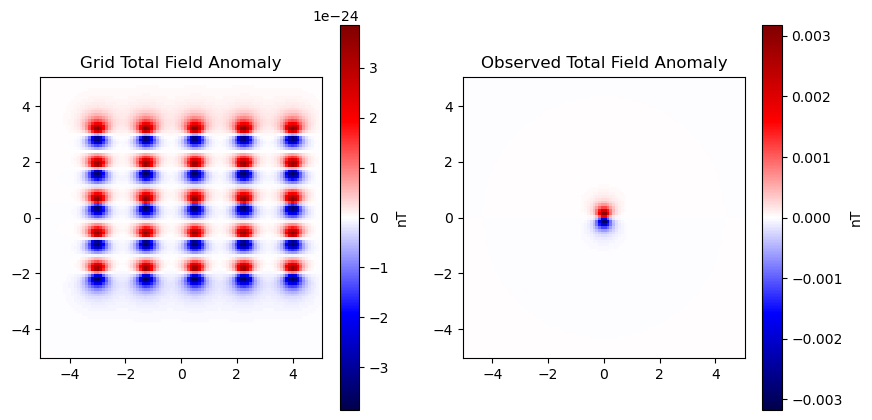

In [26]:
plt.figure(figsize=(10, 5))
scale = vd.maxabs(grid_data)
plt.subplot(1, 2, 1)
plt.pcolormesh(grid_coord[0], grid_coord[1], grid_data, cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('Grid Total Field Anomaly')
plt.axis("scaled")

plt.subplot(1,2,2)
scale_obs = vd.maxabs(observed_data)
plt.pcolormesh(grid_coord[0], grid_coord[1],grid_obs ,cmap="seismic", vmin=-scale_obs, vmax=scale_obs)
plt.colorbar(label='nT')
plt.title('Observed Total Field Anomaly')
plt.axis("scaled")

plt.show()

Text(0.5, 1.0, 'Difference')

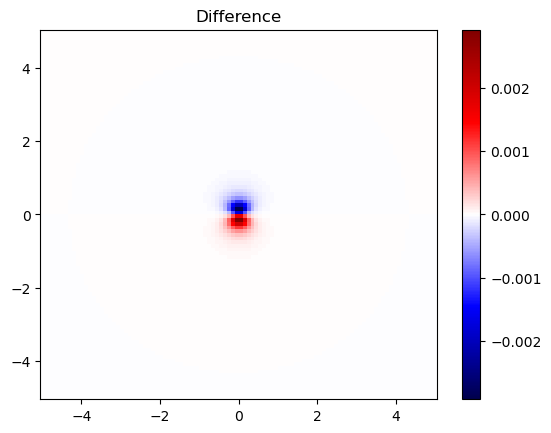

In [27]:
diff = grid_data - grid_obs
scale = vd.maxabs(diff)
plt.pcolormesh(grid_coord[0], grid_coord[1], diff,cmap="seismic", vmin=-scale, vmax=scale)
plt.colorbar()
plt.title('Difference')

In [ ]:
mse = np.square(diff).mean() 
rmse = np.sqrt(mse)
rmse

np.float64(0.00010659061703715551)